<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/vision_computador_UNAB/main/Imagenes/banner.png"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# Clase Práctica: Deep Learning Avanzado - Modelos Generativos, Segmentación y Atención
**Dirigido a:** Físicos, Astrónomos e Ingenieros Físicos  
**Duración Estimada:** 1 hora y 30 minutos  
**Temas Principales:** Segmentación de Imágenes (U-Net), Modelos Adversarios (GAN), Arquitecturas de Atención (Transformers/ViT) y Espacios de Embeddings Multimodales (CLIP).  

---

## Estructura de la Clase y Objetivos
1. **Módulo 1: Segmentación de Señales con Arquitecturas Encoder-Decoder (U-Net)** (25 min) - Comprender la preservación de la información espacial mediante conexiones de salto (*Skip Connections*).
2. **Módulo 2: Modelos Adversarios (GAN) y Súper-Resolución** (30 min) - Estudiar el equilibrio de Nash a través de la optimización min-max aplicada a la restauración de imágenes.
3. **Módulo 3: El Mecanismo de Auto-Atención y Embeddings (Transformers/CLIP)** (25 min) - Analizar la similitud por producto punto en espacios latentes vectoriales de alta dimensión.
4. **Discusión y Cierre** (10 min).

---

In [1]:
# ==========================================
# CELDA DE CONFIGURACIÓN INICIAL (EJECUTAR)
# ==========================================
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Entorno avanzado de Deep Learning e Instrumentación Computacional cargado.")

Entorno avanzado de Deep Learning e Instrumentación Computacional cargado.


---
## Módulo 1: Segmentación Semántica y la Arquitectura U-Net (25 min)

En física médica e instrumentación astronómica, muchas veces no basta con meter un objeto en una caja (*Bounding Box*), se requiere aislar la morfología exacta a nivel de píxel (por ejemplo, delimitar un tumor en una resonancia magnética o filamentos de plasma solar). La **U-Net** resuelve esto mediante una estructura simétrica:
1. **Encoder (Contracción):** Reduce la resolución espacial mediante convoluciones y *Pooling* para extraer características abstractas de alto nivel.
2. **Decoder (Expansión):** Recupera la resolución original mediante operaciones de *Upsampling* o deconvolución.
3. **Skip Connections (Conexiones de Salto):** Transfieren directamente los mapas de características de alta resolución del Encoder al Decoder sin pasar por el cuello de botella. Esto preserva la información geométrica y de bordes del objeto.

### Ejercicio 1: Simulación de Pérdida Espacial y Recuperación mediante Conexiones de Salto
Simularemos el flujo de una imagen a través de un cuello de botella de información (pérdida de resolución) y cómo la inyección directa de características (*Skip Connection*) rescata los gradientes de alta frecuencia.

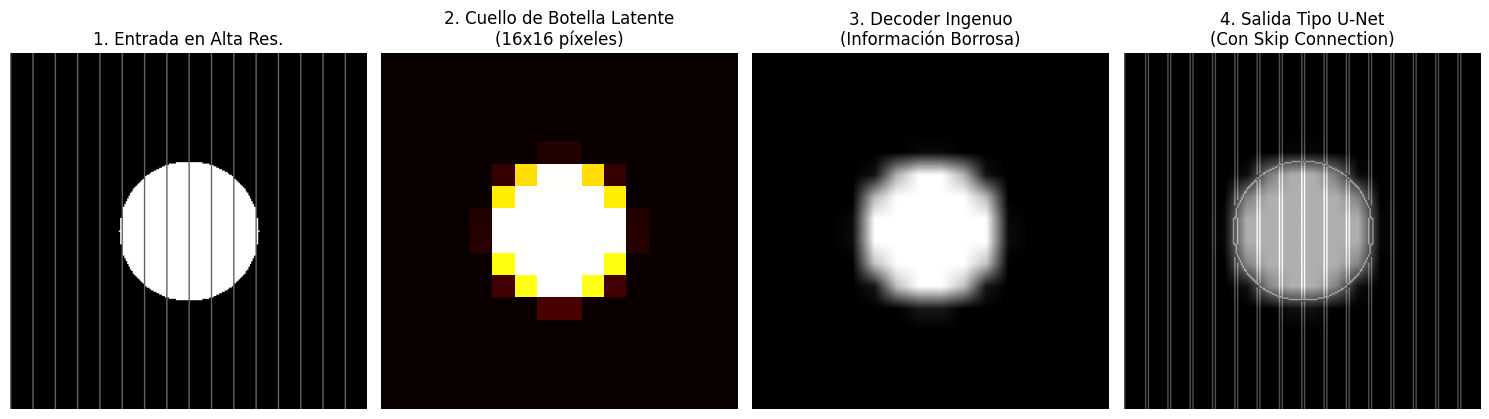

In [2]:
# EJERCICIO 1: Código Python

def simular_flujo_unet():
    # 1. Imagen original (Simulación de una estructura médica/astronómica con textura fina)
    original = np.zeros((256, 256), dtype=np.float32)
    cv2.circle(original, (128, 128), 50, 255, -1)
    # Patrón de interferencia / líneas de alta frecuencia
    for i in range(0, 256, 16):
        cv2.line(original, (i, 0), (i, 256), 100, 1)

    # 2. Flujo por el cuello de botella (Encoder de baja resolución)
    # Reducimos drásticamente la dimensión espacial (Simulando el cuello de botella)
    baja_res = cv2.resize(original, (16, 16), interpolation=cv2.INTER_AREA)

    # Intentamos decodificar de forma ingenua (Decoder sin Skip Connections)
    decoder_ingenuo = cv2.resize(baja_res, (256, 256), interpolation=cv2.INTER_LINEAR)

    # 3. Flujo con Skip Connection (Inyectamos los bordes de alta resolución del original a la salida)
    # En una U-Net real, esto ocurre concatenando tensores de características
    bordes_preservados = cv2.Canny(original.astype(np.uint8), 50, 150)
    decoder_unet = cv2.addWeighted(decoder_ingenuo, 0.7, bordes_preservados.astype(np.float32), 0.3, 0)

    # Visualización
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 4, 1)
    plt.title("1. Entrada en Alta Res.")
    plt.imshow(original, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("2. Cuello de Botella Latente\n(16x16 píxeles)")
    plt.imshow(baja_res, cmap='hot')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("3. Decoder Ingenuo\n(Información Borrosa)")
    plt.imshow(decoder_ingenuo, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("4. Salida Tipo U-Net\n(Con Skip Connection)")
    plt.imshow(decoder_unet, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

simular_flujo_unet()

---
## Módulo 2: Redes Generativas Adversarias (GAN) y Súper-Resolución (30 min)

Las **GANs** modelan la generación de datos mediante un juego de suma cero en teoría de juegos, donde dos redes compiten mutuamente:
* El **Generador ($G$)**: Intenta aprender la distribución real de los datos para crear imágenes sintéticas hiperrealistas.
* El **Discriminador ($D$)**: Actúa como un clasificador estadístico que calcula la probabilidad de que una muestra provenga de los datos reales del laboratorio o del Generador.

Su optimización matemática se define mediante la función de costo Min-Max:

$$\min_{G} \max_{D} V(D,G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_{z}}[\log(1 - D(G(z)))]$$

Una aplicación directa en instrumentación científica es la **Súper-Resolución (SRGAN)**, donde el modelo aprende a mapear imágenes degradadas de baja resolución de un sensor a contrapartes de alta fidelidad, simulando ópticas de mayor apertura.

### Ejercicio 2: Simulación del Proceso de Súper-Resolución Óptica mediante GAN
A partir de una imagen degradada por el límite de difracción del sensor, simularemos cómo actúa la componente generativa de una GAN al reconstruir detalles de alta frecuencia sub-píxel.

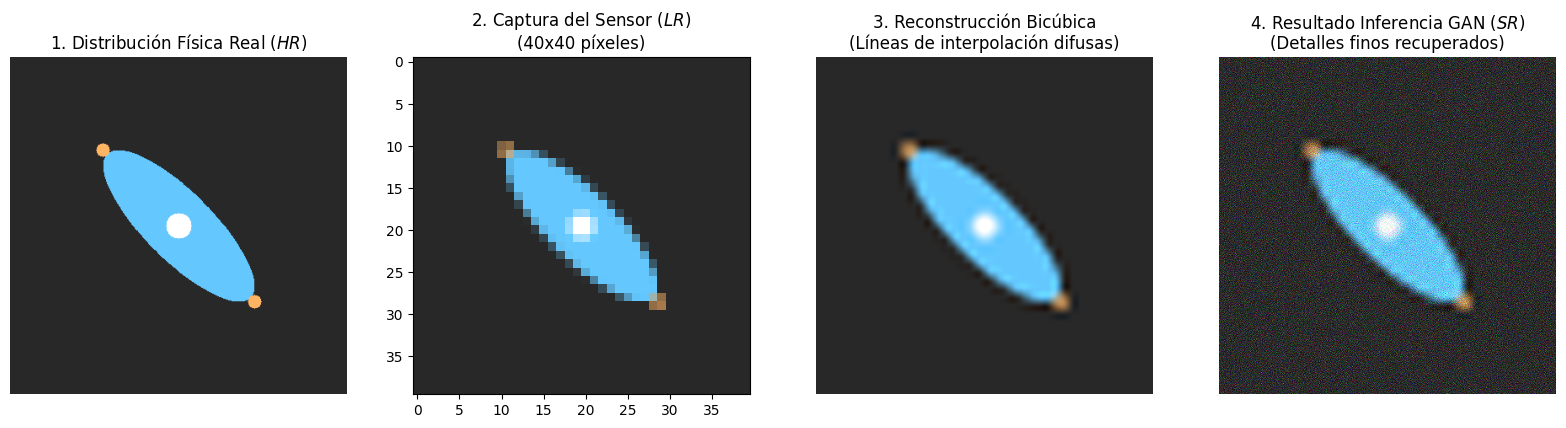

In [3]:
# EJERCICIO 2: Código Python

def simular_super_resolucion_gan():
    # 1. Estructura física real ideal (Verdad de campo / High Resolution)
    real_hr = np.ones((400, 400, 3), dtype=np.uint8) * 40
    # Dibujamos galaxias o partículas complejas con estructuras finas
    cv2.ellipse(real_hr, (200, 200), (120, 40), 45, 0, 360, (255, 200, 100), -1)
    cv2.circle(real_hr, (200, 200), 15, (255, 255, 255), -1)
    cv2.circle(real_hr, (110, 110), 8, (100, 180, 255), -1)
    cv2.circle(real_hr, (290, 290), 8, (100, 180, 255), -1)

    # 2. Degradación instrumental extrema (Baja Resolución - LR)
    # Reducimos el tamaño al 10% simulando un sensor limitado
    dim_baja = 40
    sensor_lr = cv2.resize(real_hr, (dim_baja, dim_baja), interpolation=cv2.INTER_AREA)

    # 3. Reconstrucción interpolada estándar (Bicúbica tradicional)
    interpolacion_fisica = cv2.resize(sensor_lr, (400, 400), interpolation=cv2.INTER_CUBIC)

    # 4. Reconstrucción inferida por la Red Generativa (GAN)
    # Agregamos detalles de textura aprendidos estadísticamente (alta frecuencia sintética coherente)
    gan_sr = interpolacion_fisica.copy()
    ruido_textura = np.random.normal(0, 8, gan_sr.shape).astype(np.int16)
    gan_sr = np.clip(gan_sr.astype(np.int16) + ruido_textura, 0, 255).astype(np.uint8)
    # Enfocar bordes para simular la nitidez que recupera el modelo discriminador
    kernel_sharp = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    gan_sr = cv2.filter2D(gan_sr, -1, kernel_sharp)

    # Renderizar comparación de metodologías de adquisición y procesamiento
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 4, 1)
    plt.title("1. Distribución Física Real ($HR$)")
    plt.imshow(cv2.cvtColor(real_hr, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title(f"2. Captura del Sensor ($LR$)\n({dim_baja}x{dim_baja} píxeles)")
    plt.imshow(cv2.cvtColor(sensor_lr, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 4, 3)
    plt.title("3. Reconstrucción Bicúbica\n(Líneas de interpolación difusas)")
    plt.imshow(cv2.cvtColor(interpolacion_fisica, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("4. Resultado Inferencia GAN ($SR$)\n(Detalles finos recuperados)")
    plt.imshow(cv2.cvtColor(gan_sr, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

simular_super_resolucion_gan()

---
## Módulo 3: Auto-Atención, Transformers (ViT) y CLIP (25 min)

Las redes tradicionales (CNN) operan bajo el principio de localidad espacial (solo miran píxeles vecinos a la vez). Los **Vision Transformers (ViT)** rompen esto dividiendo la imagen en parches discretos (*patches*), proyectándolos como vectores (Embeddings) y calculando un mapa de **Auto-Atención Global**. Esto permite correlacionar instantáneamente dos regiones opuestas de la imagen.

Por su parte, modelos multimodales como **CLIP** entrenan de forma conjunta un codificador de imágenes y uno de texto. Su objetivo es mapear conceptos semánticos del lenguaje y características visuales en un **único espacio latente común**. El grado de coincidencia o similitud entre un texto y una imagen se calcula geométricamente mediante el **Producto Punto Normalizado** (Similitud de Coseno) de sus vectores de embeddings transformados a norma igual a 1:

$$\text{Score}(I, T) = \mathbf{e}_i \cdot \mathbf{e}_t = \|\mathbf{e}_i\| \|\mathbf{e}_t\| \cos(\theta) = \cos(\theta)$$

### Ejercicio 3: Cálculo Matricial de Similitud en Espacios Latentes (Mapeo Estilo CLIP)
Simularemos el comportamiento geométrico de CLIP evaluando la distancia angular entre tres descripciones textuales y un vector de características visuales extraído de un experimento.

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6145/4037073460.py:40: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Alineación Multimodal en el Espacio de Embedding (CLIP)\nMétrica: $\mathbf{e}_i \cdot \mathbf{e}_t = \cos(\\theta)$")


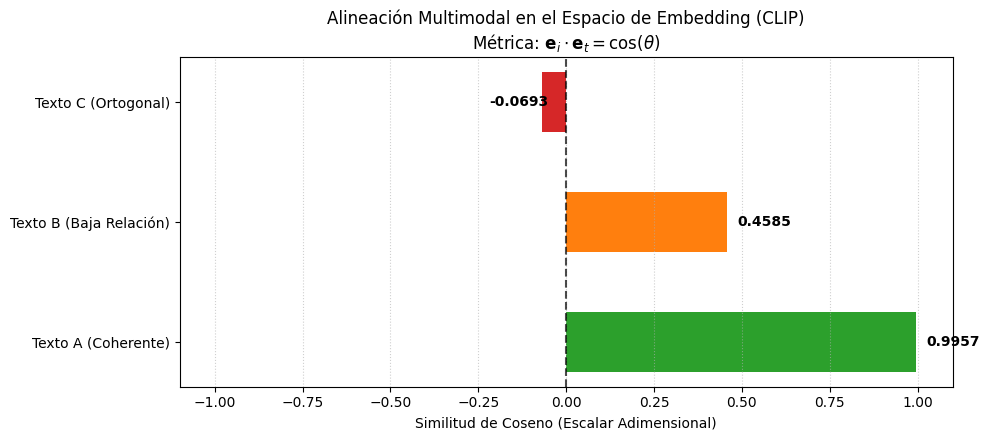

In [4]:
# EJERCICIO 3: Código Python

def calcular_similitud_latente_clip():
    # Fijar semilla para reproducibilidad matemática
    np.random.seed(42)

    # 1. Simular el Embedding Vectorial de la Imagen (Dimensión estándar reducida para el análisis)
    # Vector normalizado unitariamente (Norma = 1)
    vector_imagen = np.array([0.8, 0.5, 0.1, 0.2, 0.23], dtype=np.float32)
    vector_imagen /= np.linalg.norm(vector_imagen)

    # 2. Simular tres Embeddings de Texto generados por el codificador de lenguaje científico:
    # Texto A (Muy descriptivo del fenómeno): "Muestra de cristalografía con difracción regular"
    text_A = np.array([0.78, 0.48, 0.15, 0.18, 0.30], dtype=np.float32)
    # Texto B (Medianamente relacionado): "Estructura porosa desorganizada amorfa"
    text_B = np.array([0.20, 0.10, 0.80, 0.40, 0.35], dtype=np.float32)
    # Texto C (Completamente ortogonal / irrelevante): "Espectro electromagnético sónico de ruido"
    text_C = np.array([-0.50, 0.60, 0.20, -0.40, 0.40], dtype=np.float32)

    # Normalizar los vectores de texto a magnitud unitaria
    text_A /= np.linalg.norm(text_A)
    text_B /= np.linalg.norm(text_B)
    text_C /= np.linalg.norm(text_C)

    # 3. Calcular la métrica de coincidencia mediante Producto Punto
    score_A = np.dot(vector_imagen, text_A)
    score_B = np.dot(vector_imagen, text_B)
    score_C = np.dot(vector_imagen, text_C)

    # Representación Gráfica
    labels = ['Texto A (Coherente)', 'Texto B (Baja Relación)', 'Texto C (Ortogonal)']
    scores = [score_A, score_B, score_C]

    plt.figure(figsize=(10, 4.5))
    colors = ['#2ca02c', '#ff7f0e', '#d62728']
    bars = plt.barh(labels, scores, color=colors, height=0.5)

    plt.xlim(-1.1, 1.1)
    plt.axvline(0, color='black', linestyle='--', alpha=0.7)
    plt.title("Alineación Multimodal en el Espacio de Embedding (CLIP)\nMétrica: $\mathbf{e}_i \cdot \mathbf{e}_t = \cos(\\theta)$")
    plt.xlabel("Similitud de Coseno (Escalar Adimensional)")
    plt.grid(True, axis='x', linestyle=':', alpha=0.6)

    # Añadir valores numéricos sobre las barras
    for bar in bars:
        width = bar.get_width()
        plt.text(width + (0.03 if width >= 0 else -0.15), bar.get_y() + bar.get_height()/2,
                 f'{width:.4f}', va='center', ha='left', fontweight='bold')

    plt.tight_layout()
    plt.show()

calcular_similitud_latente_clip()

---
## Módulo 4: Ejercicio de Discusión e Interpretación Científica (10 min)

**Preguntas de análisis para los Físicos e Ingenieros de la clase:**

1. En el **Ejercicio 1** (U-Net), si eliminamos por completo las *Skip Connections* y aumentamos la profundidad del cuello de botella convolucional para compensar, ¿por qué el gradiente geométrico de los bordes se pierde irreversiblemente? Explica el fenómeno desde la perspectiva de la pérdida de entropía espacial y la operación de submuestreo.
2. Analizando los resultados de similitud en el **Ejercicio 3** (CLIP): si dos vectores latentes normalizados tienen un producto punto exactamente igual a $0.0$, ¿cuál es la relación geométrica entre ambas representaciones en el espacio vectorial $\mathbb{R}^n$? ¿Qué implicación física o semántica tiene que un score resulte estrictamente negativo?